# Preparing and Executing a NOAA NGEN Simulation



The purpose of this notebook is to demonstrate how CIROH-developed tools can be used to construct and execute a model simulation within the NOAA Next Generation (NGEN) modeling framework.



**Requirements**

* NGIAB Data Preprocessor

## 0. Introduction to the NGIAB Data Preprocessor Tools

The NGIAB Data Preprocessor tools are designed to assist in the prepartion of data needed to run NextGen model simulations. The outputs of this tool are specifically designed to execute in the NextGen-in-a-Box (NGIAB) system.

It uses geometry and model attributes from the v2.2 hydrofabric, raw forcing data can be collected from either the NWM Retrospective v3 or the AORC 1km gridded data. This tool is able to perform the following tasks:

1. Subset (delineate) the NextGen HydroFabric based on a user-provided point of interest (catchment, gage, flowpath etc).
2. Collect and prepare model forcings using the `exact extract` methodology.
3. Create the simulation configuration files needed to run a model simulation.
4. Execute model simulations using the NGIAB tools.


The `NGIAB Data Preprocessor` tools can be executed from the commandline using the sytax:

```
python -m <module name> <args>
```

for example

```
python -m ngiab_data_cli --help
```

While the `ngiab_data_cli` commands listed in this notebook can be executed within their respective cells, it is recommended that they are instead executed in a terminal window. The recommended way to do this is by opening a Jupyter Terminal window and docking it alongside the notebook instructions, for example.

![Jupyter Screenshot](./img/jupyter-screenshot.png)


## 1. Collect HydroFabric Data

Open the USGS map view to identify a location of interest. Note the stream gage number because this will be used to collect HydroFabric data for our NGEN simulation. [USGS National Water Information System Map](https://maps.waterdata.usgs.gov/mapper/index.html)


![USGS Gage Location](./img/usgs-gage-location.png)

In [53]:
# define our site number for later.
usgs_site_number = '02464000'

First lets make a directory to store our output data. To do this, issue the following command and insert your desired USGS gage in place of the one below.

```bash
mkdir "$(pwd)/ngen-02464000"
```

This can be executed in the notebook using the following command:


<div style="border-left: 3px solid red; padding-left: 10px;">
<pre>
    !mkdir "$(pwd)/ngen-02464000"
</pre>
</div>


Subset the HydroFabric at our desired gage using the following command:

```
python -m ngiab_data_cli -i gage-02464000 --output_name "$(pwd)/ngen-02464000/hf-02464000" --subset
```

|Command| Description|
|---|---|
|`-m ngiab_data_cli` | tells Python which module it should run   |
|`-i gage-02464000`  | the input feature to subset   |
|`-o $(pwd)/ngen-02464000/hf-02464000` | the location to save hydrofabric output | 
|`--subset`          | indicates that the hydrofabric subsetting operation should be  performed. |

---

The same command can be executed within the notebook using the following command:

<div style="border-left: 3px solid red; padding-left: 10px;">
<pre>
usgs_site_number = '02464000'
<br>
!python -m ngiab_data_cli -i gage-{usgs_site_number} --output_name "$(pwd)/ngen-{usgs_site_number}/hf-{usgs_site_number}" --subset

</pre>
</div>

We can preview these data using `Fiona` and `GeoPandas`.

In [73]:
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

# define the path to our geopackage file
hf_filepath = f"./ngen-{usgs_site_number}/hf-{usgs_site_number}_subset.gpkg"

Since our geopackage may contain more than one layer, we'll first use `fiona` to list the layers that are available.

In [74]:
layers = fiona.listlayers(hf_filepath)

print( 45*'-' + '\nThe Geopackage contains the following layers: \n' + 45*'-')
for layer in layers:
    print(layer)

---------------------------------------------
The Geopackage contains the following layers: 
---------------------------------------------
flowpaths
divides
lakes
hydrolocations
nexus
pois
flowpath-attributes
flowpath-attributes-ml
network
divide-attributes


Let's load and plot the `divides`, `flowpaths`, and `nexus` layers.

In [75]:
# load the layers
divides = gpd.read_file(hf_filepath, layer="divides")
flowpaths = gpd.read_file(hf_filepath, layer="flowpaths")
nexus = gpd.read_file(hf_filepath, layer="nexus")

print(f'{len(divides)} Divides')
print(f'{len(flowpaths)} Flowpaths')
print(f'{len(nexus)} Nexus')

74 Divides
74 Flowpaths
35 Nexus


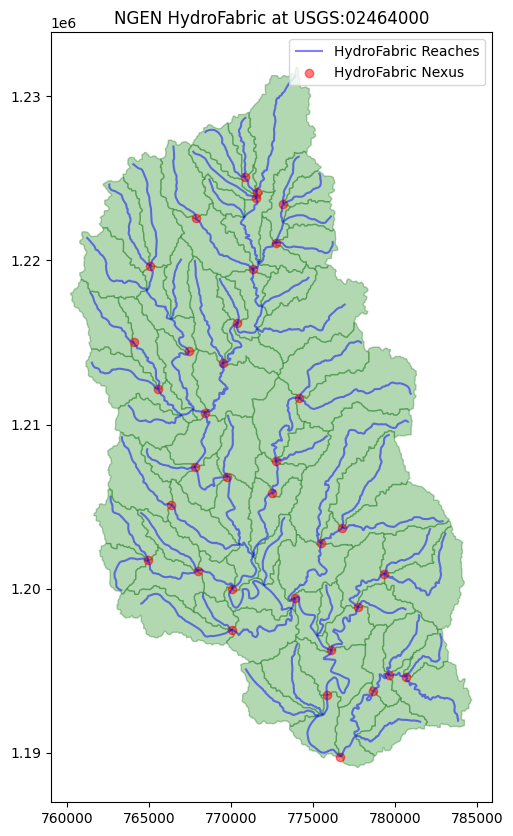

In [76]:
# create a figure
fig, ax = plt.subplots(figsize=(10, 10))

divides.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen')
flowpaths.plot(ax=ax, color='blue', edgecolor='blue', alpha=0.5, label='HydroFabric Reaches')
nexus.plot(ax=ax, color='red', edgecolor='red', alpha=0.5, label='HydroFabric Nexus')

plt.title(f'NGEN HydroFabric at USGS:{usgs_site_number}')
ax.legend()
plt.show()

Each of these GeoPandas dataframes contains attributes that we can look at as well.

In [77]:
divides

,divide_id,toid,type,ds_id,areasqkm,vpuid,id,lengthkm,tot_drainage_areasqkm,has_flowline,geometry
0,cat-485481,nex-485432,network,NaN,8.491950,03W,wb-485481,6.032870,8.491950,True,"POLYGON ((771945 1191915, 771855 1191795, 7717..."
1,cat-485482,nex-485432,network,NaN,8.202150,03W,wb-485482,5.686699,8.202150,True,"POLYGON ((774495 1194915, 774585 1194765, 7747..."
2,cat-485537,nex-485538,network,NaN,13.331250,03W,wb-485537,7.376040,17.030250,True,"POLYGON ((782745 1191555, 782595 1191555, 7825..."
3,cat-485424,nex-485425,network,NaN,13.820850,03W,wb-485424,5.396450,154.494900,True,"POLYGON ((769365 1210215, 769215 1210185, 7692..."
4,cat-485497,nex-485494,network,NaN,7.837651,03W,wb-485497,4.924936,7.837651,True,"POLYGON ((763905 1202445, 763785 1202565, 7637..."
...,...,...,...,...,...,...,...,...,...,...,...
69,cat-485483,nex-485484,network,NaN,15.554251,03W,wb-485483,8.035247,15.554251,True,"POLYGON ((782835 1197525, 782895 1197585, 7829..."
70,cat-485487,nex-485484,network,NaN,7.776900,03W,wb-485487,4.532541,7.776900,True,"POLYGON ((779355 1200885, 779355 1200945, 7794..."
71,cat-485484,nex-485485,network,NaN,8.231850,03W,wb-485484,4.199826,31.563001,True,"POLYGON ((776895 1198785, 776955 1198815, 7770..."
72,cat-485486,nex-485485,network,NaN,5.423400,03W,wb-485486,3.438493,5.423400,True,"POLYGON ((779535 1197645, 779715 1197765, 7797..."


We can add attach additional attributes to these divide features.

In [78]:
divide_attrs = gpd.read_file(hf_filepath, layer="divide-attributes")
merged_divides = divides.merge(divide_attrs, on='divide_id')

merged_divides

,divide_id,toid,type,ds_id,areasqkm,vpuid_x,id,lengthkm,tot_drainage_areasqkm,has_flowline,...,mean.Zmax,mode.Expon,centroid_x,centroid_y,mean.impervious,mean.elevation,mean.slope,circ_mean.aspect,dist_4.twi,vpuid_y
0,cat-485481,nex-485432,network,NaN,8.491950,03W,wb-485481,6.032870,8.491950,True,...,226.44128,7.0,771945.000075,1.193580e+06,0.0,12023.159894,79.307302,165.991320,"[{""v"":4.902,""frequency"":0.2513},{""v"":7.265,""fr...",03W
1,cat-485482,nex-485432,network,NaN,8.202150,03W,wb-485482,5.686699,8.202150,True,...,226.44128,7.0,773490.000150,1.194615e+06,0.0,11994.912711,75.608828,163.789487,"[{""v"":4.751,""frequency"":0.2486},{""v"":7.643,""fr...",03W
2,cat-485537,nex-485538,network,NaN,13.331250,03W,wb-485537,7.376040,17.030250,True,...,226.44128,7.0,782280.000000,1.193685e+06,0.0,13783.876641,79.708702,187.035765,"[{""v"":5.638,""frequency"":0.25},{""v"":7.175,""freq...",03W
3,cat-485424,nex-485425,network,NaN,13.820850,03W,wb-485424,5.396450,154.494900,True,...,226.44128,7.0,770319.000027,1.212330e+06,0.0,13042.294842,72.572108,191.536519,"[{""v"":5.823,""frequency"":0.2509},{""v"":7.421,""fr...",03W
4,cat-485497,nex-485494,network,NaN,7.837651,03W,wb-485497,4.924936,7.837651,True,...,226.42044,7.0,763297.499925,1.203915e+06,0.0,14065.478773,80.552520,174.131412,"[{""v"":4.228,""frequency"":0.25},{""v"":7.058,""freq...",03W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,cat-485483,nex-485484,network,NaN,15.554251,03W,wb-485483,8.035247,15.554251,True,...,226.44128,7.0,781726.071237,1.200675e+06,0.0,15807.695191,82.981127,193.810020,"[{""v"":5.869,""frequency"":0.25},{""v"":6.95,""frequ...",03W
70,cat-485487,nex-485484,network,NaN,7.776900,03W,wb-485487,4.532541,7.776900,True,...,226.44128,7.0,780780.000150,1.202490e+06,0.0,15350.458104,82.076041,199.791528,"[{""v"":4.704,""frequency"":0.2485},{""v"":6.718,""fr...",03W
71,cat-485484,nex-485485,network,NaN,8.231850,03W,wb-485484,4.199826,31.563001,True,...,226.44128,7.0,777993.749691,1.201095e+06,0.0,13062.403708,80.146869,178.574275,"[{""v"":5.579,""frequency"":0.2528},{""v"":7.077,""fr...",03W
72,cat-485486,nex-485485,network,NaN,5.423400,03W,wb-485486,3.438493,5.423400,True,...,226.44128,7.0,779388.750127,1.199025e+06,0.0,13806.055699,82.177182,196.234564,"[{""v"":3.545,""frequency"":0.25},{""v"":6.926,""freq...",03W


Notice there are 50 columns as opposed to the 11 in the original dataframe. We list all of the columns too.

In [79]:
for c in merged_divides.columns:
    print(c)

divide_id
toid
type
ds_id
areasqkm
vpuid_x
id
lengthkm
tot_drainage_areasqkm
has_flowline
geometry
mode.bexp_soil_layers_stag=1
mode.bexp_soil_layers_stag=2
mode.bexp_soil_layers_stag=3
mode.bexp_soil_layers_stag=4
mode.ISLTYP
mode.IVGTYP
geom_mean.dksat_soil_layers_stag=1
geom_mean.dksat_soil_layers_stag=2
geom_mean.dksat_soil_layers_stag=3
geom_mean.dksat_soil_layers_stag=4
geom_mean.psisat_soil_layers_stag=1
geom_mean.psisat_soil_layers_stag=2
geom_mean.psisat_soil_layers_stag=3
geom_mean.psisat_soil_layers_stag=4
mean.cwpvt
mean.mfsno
mean.mp
mean.refkdt
mean.slope_1km
mean.smcmax_soil_layers_stag=1
mean.smcmax_soil_layers_stag=2
mean.smcmax_soil_layers_stag=3
mean.smcmax_soil_layers_stag=4
mean.smcwlt_soil_layers_stag=1
mean.smcwlt_soil_layers_stag=2
mean.smcwlt_soil_layers_stag=3
mean.smcwlt_soil_layers_stag=4
mean.vcmx25
mean.Coeff
mean.Zmax
mode.Expon
centroid_x
centroid_y
mean.impervious
mean.elevation
mean.slope
circ_mean.aspect
dist_4.twi
vpuid_y


We can do the same thing for the flowpaths.

In [80]:
flow_attrs = gpd.read_file(hf_filepath, layer="flowpath-attributes")
merged_flows = flowpaths.merge(flow_attrs, on='id')
for c in merged_flows.columns:
    print(c)

id
toid_x
mainstem
order
hydroseq
lengthkm
areasqkm
tot_drainage_areasqkm
has_divide
divide_id
poi_id
vpuid_x
geometry
link
to
Length_m
Y
n
nCC
BtmWdth
TopWdth
TopWdthCC
ChSlp
alt
So
MusX
MusK
gage
gage_nex_id
WaterbodyID
waterbody_nex_id
toid_y
vpuid_y


## 2. Collect Model Forcings

In [85]:
import xarray

Now that we have an NGEN HydroFabric for our location of interest, we can collect meteorlogical forcing data. This can be done using the `NGIAB Data Preprocessor`.

```
python -m ngiab_data_cli -i gage-02464000 --output_name "$(pwd)/ngen-02464000/hf-02464000" -f --start 2023-01-01 --end 2023-02-28
```


|Command| Description|
|---|---|
|`-m ngiab_data_cli` | tells Python which module it should run   |
|`-i gage-02464000`  | the input feature to subset   |
|`-o $(pwd)/ngen-02464000` | the directory to save the forcings | 
|`-f`          | indicates that the forcing collection operation should be executed |
|`--start 2025-01-01`          | the start time for data collection |
|`--end 2025-02-28`          | the end time for data collection |

---

The same command can be executed within the notebook using the following command:

<div style="border-left: 3px solid red; padding-left: 10px;">
<pre>
usgs_site_number = '02464000'
<br>
!python -m ngiab_data_cli -i gage-{usgs_site_number} --output_name "$(pwd)/ngen-{usgs_site_number}/hf-{usgs_site_number}" -f --start 2023-01-01 --end 2023-02-28

</pre>
</div> 

We can preview these data using the `Xarray` library.

In [81]:
forcing_path = f'./ngen-{usgs_site_number}/hf-{usgs_site_number}/forcings/forcings.nc'

In [86]:
ds = xarray.open_dataset(forcing_path)
ds

<xarray.Dataset> Size: 2MB
Dimensions:              (catchment-id: 74, time: 744)
Dimensions without coordinates: catchment-id, time
Data variables:
    DLWRF_surface        (catchment-id, time) float32 220kB ...
    PRES_surface         (catchment-id, time) float32 220kB ...
    SPFH_2maboveground   (catchment-id, time) float32 220kB ...
    precip_rate          (catchment-id, time) float32 220kB ...
    DSWRF_surface        (catchment-id, time) float32 220kB ...
    TMP_2maboveground    (catchment-id, time) float32 220kB ...
    UGRD_10maboveground  (catchment-id, time) float32 220kB ...
    VGRD_10maboveground  (catchment-id, time) float32 220kB ...
    APCP_surface         (catchment-id, time) float32 220kB ...
    ids                  (catchment-id) <U10 3kB ...
    Time                 (catchment-id, time) int32 220kB ...

## 3. Generate Model Configuration Files

Now that we have an NGEN HydroFabric for our location of interest and the forcing data for our time period, we're ready to configure the model using the `NGIAB Data Preprocessor`.

```
python -m ngiab_data_cli -i gage-02464000 --output_name "$(pwd)/ngen-02464000/hf-02464000" -r --start 2023-01-01 --end 2023-02-28
```


|Command| Description|
|---|---|
|`-m ngiab_data_cli` | tells Python which module it should run   |
|`-i gage-02464000`  | the input feature to subset   |
|`-o $(pwd)/ngen-02464000` | the directory to save the forcings | 
|`-r`          | indicates that the configuration files should be createed |
|`--start 2025-01-01`          | the start time for our simulation|
|`--end 2025-02-28`          | the end time for our simulation|

---

The same command can be executed within the notebook using the following command:

<div style="border-left: 3px solid red; padding-left: 10px;">
<pre>
usgs_site_number = '02464000'
<br>
!python -m ngiab_data_cli -i gage-{usgs_site_number} --output_name "$(pwd)/ngen-{usgs_site_number}/hf-{usgs_site_number}" -r --start 2023-01-01 --end 2023-02-28

</pre>
</div> 

List the configuration files that were generate by this previous command:

```
tree "$(pwd)/ngen-02464000/hf-02464000"
```


The same command can be executed within the notebook using the following command:
<div style="border-left: 3px solid red; padding-left: 10px;">
<pre>
tree $(pwd)/ngen-{usgs_site_number}/hf-{usgs_site_number}
</pre>
</div> 

## 4. Executing a Simulation


```
python -m ngiab_data_cli -i gage-02464000 --output_name "$(pwd)/ngen-02464000/hf-02464000" --run
```


|Command| Description|
|---|---|
|`-m ngiab_data_cli` | tells Python which module it should run   |
|`-i gage-02464000`  | the input feature to subset   |
|`-o $(pwd)/ngen-02464000` | the directory to save the forcings | 
|`--run`          | indicates that the model execution function should be invoked |

---

The same command can be executed within the notebook using the following command:

<div style="border-left: 3px solid red; padding-left: 10px;">
<pre>
usgs_site_number = '02464000'
<br>
!python -m ngiab_data_cli -i gage-{usgs_site_number} --output_name "$(pwd)/ngen-{usgs_site_number}/hf-{usgs_site_number}" --run

</pre>
</div> 

## 5. Evaluating Simulation Results